In [7]:
from langgraph.graph import StateGraph, END, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from dotenv import load_dotenv

from langchain_core.messages import RemoveMessage

load_dotenv()

True

In [8]:
LLM = ChatGroq(model="openai/gpt-oss-20b", temperature=0.5)

In [9]:
def chat_node(state: MessagesState):
    response = LLM.invoke(state['messages'])
    return {'messages': [response]}

def clean_up(state: MessagesState):
    msg = state['messages']
    
    # now suppose we are checking for the recent messages of 10
    if len(msg)>10:
        #agar 10 se jada msg aagye toh usmye se 6 ko hata do and 4 hi rakho.
        #removin the 6 messages from the state
        to_remove =  msg[:6]
        return {'messages': [RemoveMessage(id=m.id) for m in to_remove]}
        
    return{}

In [10]:
#building the graph
graph = StateGraph(MessagesState)
graph.add_node("chat_node", chat_node)
graph.add_node("clean_up", clean_up)

graph.add_edge(START,"chat_node")
graph.add_edge("chat_node", "clean_up")
graph.add_edge("clean_up", END)

memory = InMemorySaver()

Summarizer = graph.compile(checkpointer=memory)



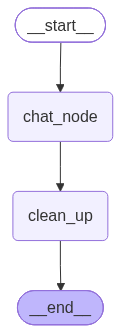

In [11]:
from IPython.display import Image
Image(Summarizer.get_graph().draw_mermaid_png())